In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.xception import Xception
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import itertools
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pickle
%matplotlib inline

In [4]:
local_zip = '/content/drive/MyDrive/data_folder.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/data_folder')
zip_ref.close()

base_dir = '/content/data_folder'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [5]:

base_dir = '/content/data_folder/data_folder'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [6]:
train_datagen = ImageDataGenerator(rescale=1.0/255.0,width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
validation_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

In [7]:
train_generator = train_datagen.flow_from_directory(train_dir, batch_size = 32, class_mode = 'binary', target_size = (224, 224))
validation_generator = validation_datagen.flow_from_directory(validation_dir,  batch_size = 32, class_mode = 'binary', target_size = (224, 224), shuffle = False)
test_generator = test_datagen.flow_from_directory(test_dir,  batch_size = 32, class_mode = 'binary', target_size = (224, 224), shuffle = False)

Found 20000 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [11]:
es = EarlyStopping(monitor='val_accuracy', patience=5,start_from_epoch=15, restore_best_weights=True)
cp1 = ModelCheckpoint('/content/drive/MyDrive/inception_model.h5', monitor='val_accuracy', save_best_only=True, mode='max',verbose=0)
cp2 = ModelCheckpoint('/content/drive/MyDrive/xception_model.h5', monitor='val_accuracy', save_best_only=True, mode='max',verbose=0)

In [9]:
base_model_list={
            'base_inception_v3': InceptionV3(input_shape=(224, 224, 3), weights='imagenet', include_top=False),
            'base_xception': Xception(input_shape=(224, 224, 3), weights='imagenet', include_top=False),
}
for model in base_model_list.values():
  for layer in model.layers:
    layer.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [12]:
#InceptionV3
x3 = layers.Flatten()(base_model_list['base_inception_v3'].output)
x3 = layers.Dense(1024, activation='relu')(x3)
x3 = layers.Dropout(0.2)(x3)
x3 = layers.Dense(1, activation='sigmoid')(x3)

inception_v3_finetuned = models.Model(base_model_list['base_inception_v3'].input, x3)

inception_v3_finetuned.compile(optimizer = optimizers.Adam(learning_rate=0.0001), loss = 'binary_crossentropy', metrics = ['accuracy'])

In [13]:
#Xception
x4 = layers.GlobalAveragePooling2D()(base_model_list['base_xception'].output)
x4 = layers.Dropout(0.5)(x4)
x4 = layers.Dense(1, activation='sigmoid')(x4)
xception_finetuned = models.Model(base_model_list['base_xception'].input, x4)

xception_finetuned.compile(optimizer = optimizers.Adam(learning_rate=0.0001), loss = 'binary_crossentropy', metrics = ['accuracy'])

In [15]:
# InceptionV3 finetuned
inception_his = inception_v3_finetuned.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=[cp1,es]
)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9834 - loss: 0.0503

625/625 ━━━━━━━━━━━━━━━━━━━━ 294s 471ms/step - accuracy: 0.9834 - loss: 0.0503 - val_accuracy: 0.9864 - val_loss: 0.0367
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 439ms/step - accuracy: 0.9862 - loss: 0.0419 - val_accuracy: 0.9848 - val_loss: 0.0626
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9856 - loss: 0.0430

625/625 ━━━━━━━━━━━━━━━━━━━━ 333s 458ms/step - accuracy: 0.9856 - loss: 0.0430 - val_accuracy: 0.9900 - val_loss: 0.0287
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 289s 463ms/step - accuracy: 0.9877 - loss: 0.0338 - val_accuracy: 0.9868 - val_loss: 0.0453
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 437ms/step - accuracy: 0.9888 - loss: 0.0313 - val_accuracy: 0.9892 - val_loss: 0.0337
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 326s 444ms/step - accuracy: 0.9902 - loss: 0.0302 - val_accuracy: 0.9876 - val_loss: 0.0445
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 275s 440ms/step - accuracy: 0.9911 - loss: 0.0266 - val_accuracy: 0.9892 - val_loss: 0.0331
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 274s 438ms/step - accuracy: 0.9907 - loss: 0.0253 - val_accuracy: 0.9888 - val_loss: 0.0312
Epoch 9/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 275s 441ms/step - accuracy: 0.9928 - loss: 0.0201 - val_accuracy: 0.9876 - val_loss: 0.0339
Epoch 10/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 275s 440ms/step - accuracy: 0.9908 - loss: 0.0

625/625 ━━━━━━━━━━━━━━━━━━━━ 337s 458ms/step - accuracy: 0.9931 - loss: 0.0203 - val_accuracy: 0.9904 - val_loss: 0.0361
Epoch 17/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 446ms/step - accuracy: 0.9935 - loss: 0.0176 - val_accuracy: 0.9896 - val_loss: 0.0323
Epoch 18/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 442ms/step - accuracy: 0.9949 - loss: 0.0146 - val_accuracy: 0.9900 - val_loss: 0.0415
Epoch 19/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9954 - loss: 0.0133

625/625 ━━━━━━━━━━━━━━━━━━━━ 336s 464ms/step - accuracy: 0.9954 - loss: 0.0133 - val_accuracy: 0.9916 - val_loss: 0.0358
Epoch 20/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 488ms/step - accuracy: 0.9940 - loss: 0.0170 - val_accuracy: 0.9916 - val_loss: 0.0336


In [ ]:
# Xception finetuned
xception_his = xception_finetuned.fit(
    train_generator,
    epochs=20,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=[cp2,es]
)


Epoch 1/20
200/200 [==============================] - 107s 494ms/step - loss: 0.4615 - acc: 0.8117 - val_loss: 0.2496 - val_acc: 0.9720
Epoch 2/20
200/200 [==============================] - 96s 478ms/step - loss: 0.2176 - acc: 0.9605 - val_loss: 0.1454 - val_acc: 0.9788
Epoch 3/20
200/200 [==============================] - 96s 479ms/step - loss: 0.1482 - acc: 0.9681 - val_loss: 0.1071 - val_acc: 0.9808
Epoch 4/20
200/200 [==============================] - 96s 481ms/step - loss: 0.1133 - acc: 0.9748 - val_loss: 0.0874 - val_acc: 0.9824
Epoch 5/20
200/200 [==============================] - 96s 481ms/step - loss: 0.0962 - acc: 0.9766 - val_loss: 0.0760 - val_acc: 0.9824
Epoch 6/20
200/200 [==============================] - 96s 479ms/step - loss: 0.0871 - acc: 0.9777 - val_loss: 0.0687 - val_acc: 0.9832
Epoch 7/20
200/200 [==============================] - 97s 485ms/step - loss: 0.0778 - acc: 0.9787 - val_loss: 0.0638 - val_acc: 0.9832
Epoch 8/20
200/200 [==============================] - 

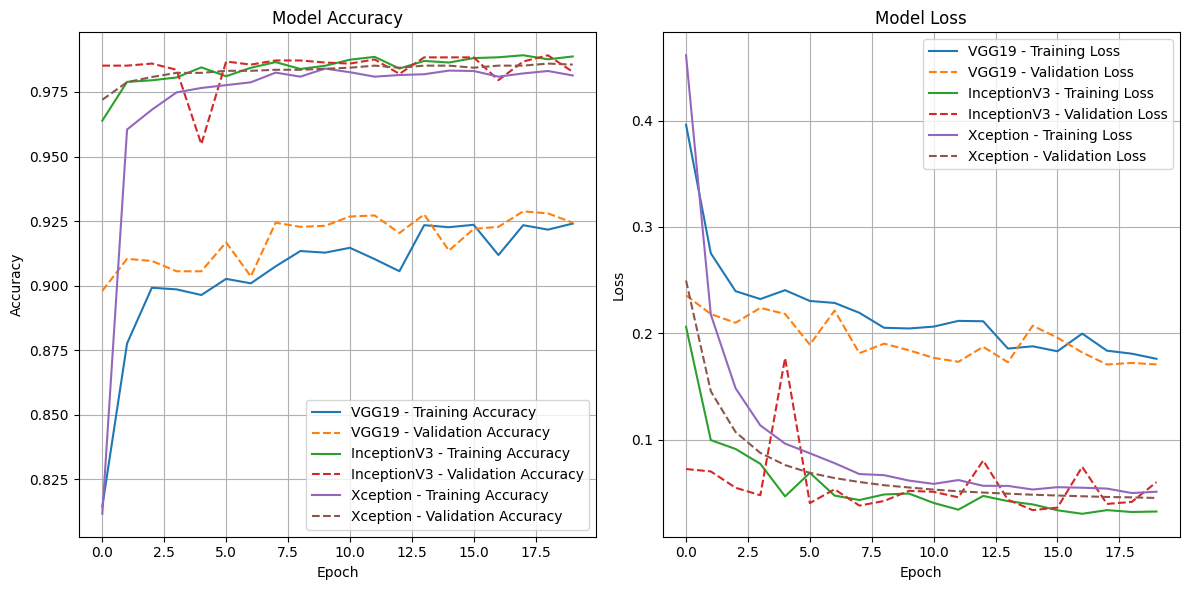

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for model_name, history in histories.items():
    plt.plot(history['acc'], label=f'{model_name} - Training Accuracy', linestyle='-')
    plt.plot(history['val_acc'], label=f'{model_name} - Validation Accuracy', linestyle='--')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for model_name, history in histories.items():
    plt.plot(history['loss'], label=f'{model_name} - Training Loss', linestyle='-')
    plt.plot(history['val_loss'], label=f'{model_name} - Validation Loss', linestyle='--')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [16]:
inception = load_model('/content/drive/MyDrive/inception_model.h5')

# xception = load_model('/content/drive/MyDrive/xception_model.h5')

In [17]:
models = {
    'InceptionV3': inception,
    # 'Xception': xception
}

In [18]:
for model in models.values():
  model.evaluate(test_generator)

79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.9917 - loss: 0.0221


79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step


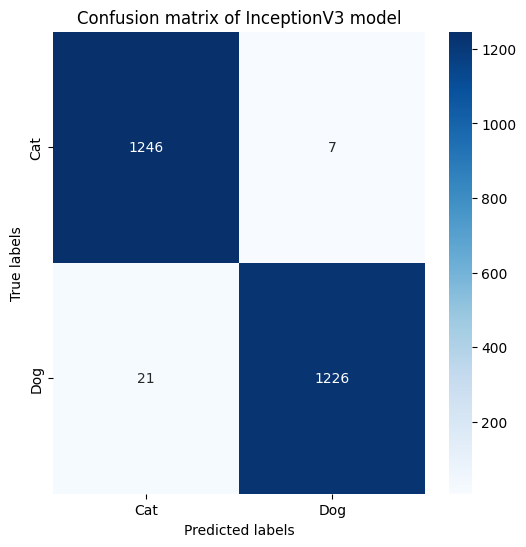

In [19]:
for name, estimator in models.items():
  predictions = estimator.predict(test_generator).flatten()
  y_pred = (predictions > 0.5).astype(int)
  cm = confusion_matrix(test_generator.classes, y_pred)
  plt.figure(figsize=(6, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
  plt.xlabel('Predicted labels')
  plt.ylabel('True labels')
  plt.title(f'Confusion matrix of {name} model')
  plt.show()

In [20]:
for name, estimator in models.items():
  predictions = estimator.predict(test_generator).flatten()
  y_pred = (predictions > 0.5).astype(int)
  print(f'Classification report of {name} model:')
  print(classification_report(test_generator.classes, y_pred, target_names=['Cat', 'Dog']))

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step
Classification report of InceptionV3 model:
              precision    recall  f1-score   support

         Cat       0.98      0.99      0.99      1253
         Dog       0.99      0.98      0.99      1247

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



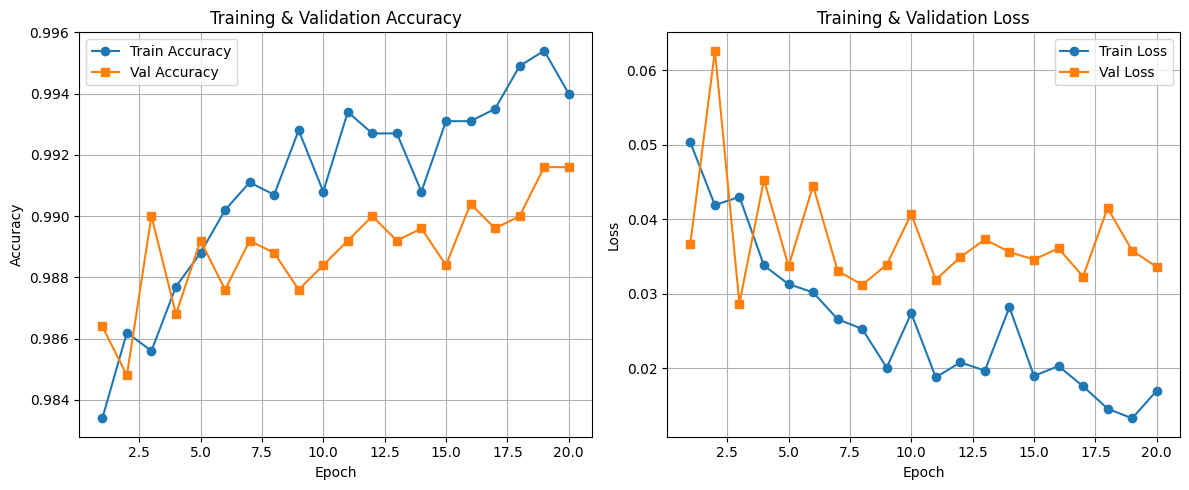

In [21]:
import matplotlib.pyplot as plt

# Các số liệu lấy từ log huấn luyện bạn cung cấp
train_acc = [
    0.9834, 0.9862, 0.9856, 0.9877, 0.9888,
    0.9902, 0.9911, 0.9907, 0.9928, 0.9908,
    0.9934, 0.9927, 0.9927, 0.9908, 0.9931,
    0.9931, 0.9935, 0.9949, 0.9954, 0.9940
]

val_acc = [
    0.9864, 0.9848, 0.9900, 0.9868, 0.9892,
    0.9876, 0.9892, 0.9888, 0.9876, 0.9884,
    0.9892, 0.9900, 0.9892, 0.9896, 0.9884,
    0.9904, 0.9896, 0.9900, 0.9916, 0.9916
]

train_loss = [
    0.0503, 0.0419, 0.0430, 0.0338, 0.0313,
    0.0302, 0.0266, 0.0253, 0.0201, 0.0274,
    0.0188, 0.0208, 0.0197, 0.0282, 0.0190,
    0.0203, 0.0176, 0.0146, 0.0133, 0.0170
]

val_loss = [
    0.0367, 0.0626, 0.0287, 0.0453, 0.0337,
    0.0445, 0.0331, 0.0312, 0.0339, 0.0407,
    0.0319, 0.0349, 0.0373, 0.0356, 0.0346,
    0.0361, 0.0323, 0.0415, 0.0358, 0.0336
]

epochs = list(range(1, 21))

# -------------------- Vẽ biểu đồ --------------------
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label="Train Accuracy", marker='o')
plt.plot(epochs, val_acc, label="Val Accuracy", marker='s')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label="Train Loss", marker='o')
plt.plot(epochs, val_loss, label="Val Loss", marker='s')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()